# 회귀 (Regreession)
KNN regression 사용

In [1]:
# 지도학습은 target y 의 형태에 따라
# 회귀(regression) 와 분류 (classification) 으로 나뉜다.

# '분류' 는 몇개의 클래스 중 하나로 분류 하는 문제
# '회귀' 는 임의의 어떤 숫자를 예측 하는 문제
#   - 내년 경제 성장률 예측, 주가 예측
#   - 주문후 배달 도착시간 예측
#   - 회귀 문제의 출력은 정해진 클래스가 아니라 '임의의 수치'

# k-최근접 이웃 회귀
k-nearest neighbor (KNN) regression

In [ ]:
# 'k-최근접 이웃 회귀' 도 비슷하다.
# '분류' 와 똑같이 예측하려는 샘플에 가장 가까운 샘플 k개를 선택합니다.
# 하지만 회귀이기 때문에 이웃한 샘플의 타깃은 어떤 클래스가 아니라 '임의의 수치' 가 된다.
# 이웃 샘플의 수치를 사용해 새로운 샘플 X 의 타킷을 예측하는 방법은 ?
# => 바로 이 수치들의 평균값을 구하면 된다.

# 데이터 준비

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
base_path = r'/content/drive/MyDrive/KoreaIT (코리아it)/250107 💚자연어처리/[AI자연어]/dataset(AI2501)'

In [4]:
file_path = os.path.join(base_path, 'fish.csv')
fish_df = pd.read_csv(file_path)
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [ ]:
# 농어의 길이(특징, feature) 가 주어졌을때 무게(target) 를 예측해보자.

In [8]:
# 농어의 길이 (feature)
perch_length = fish_df[fish_df.Species == 'Perch']['Length'].values
print(perch_length)

# 농어의 무게 (target)
perch_weight = fish_df[fish_df.Species == 'Perch']['Weight'].values
print(perch_weight)



[ 8.4 13.7 15.  16.2 17.4 18.  18.7 19.  19.6 20.  21.  21.  21.  21.3
 22.  22.  22.  22.  22.  22.5 22.5 22.7 23.  23.5 24.  24.  24.6 25.
 25.6 26.5 27.3 27.5 27.5 27.5 28.  28.7 30.  32.8 34.5 35.  36.5 36.
 37.  37.  39.  39.  39.  40.  40.  40.  40.  42.  43.  43.  43.5 44. ]
[   5.9   32.    40.    51.5   70.   100.    78.    80.    85.    85.
  110.   115.   125.   130.   120.   120.   130.   135.   110.   130.
  150.   145.   150.   170.   225.   145.   188.   180.   197.   218.
  300.   260.   265.   250.   250.   300.   320.   514.   556.   840.
  685.   700.   700.   690.   900.   650.   820.   850.   900.  1015.
  820.  1100.  1000.  1100.  1000.  1000. ]


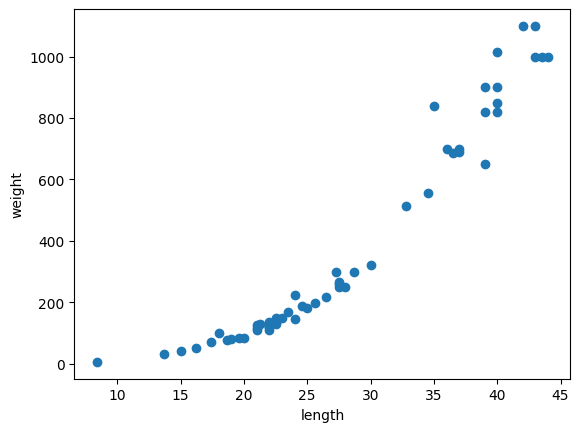

In [9]:
# 시각화
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

In [12]:
train_input, test_input, train_target, test_target = \
  train_test_split(perch_length, perch_weight, random_state=42)

In [13]:
train_input.shape, test_input.shape

((42,), (14,))

In [14]:
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [15]:
train_input.shape, test_input.shape

((42, 1), (14, 1))

# 결정 계수 ($R^2$)


KNeighborsRegressor 의 score 값

In [16]:
from sklearn.neighbors import KNeighborsRegressor

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#kneighborsregressor

```python
class sklearn.neighbors.KNeighborsRegressor(
  n_neighbors=5,
  *,
  weights='uniform',
  algorithm='auto',
  leaf_size=30,
  p=2,
  metric='minkowski',
  metric_params=None,
  n_jobs=None)
```

In [17]:
knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

KNeighborsRegressor()

In [18]:
knr.score(test_input, test_target)

0.992809406101064

In [ ]:
"""
매우 높은 점수가 나왔다?  이 점수는 무엇일까?
'분류' 문제의 경우 test 세트의 샘플을 정확하게 분류한 개수의 비율이다. (accuracy: 정확도)
'회귀' 문제는 정확한 숫자를 맞힌다는것이 거의 불가능하다.
예측하는 값이나 타킷 모두 임의의 수치이기 때문이다.

'회귀' 의 경우 평가방식이 조금 다르다
이 점수를 '결정계수' (coeffiencit of determination) 이라고 부름.
간단히 R² 라고도 부름

이 값은 다음과 같은 식으로 계산됨

          (target - 예측)² 의 합
 R² = 1 - ──────────────────
          (target - 평균)² 의 합

"""
None

In [19]:
from sklearn.metrics import mean_absolute_error  # target 과 예측의 절대값 오차를 평균하여 리턴.

In [20]:
# 테스트 세트에 대한 예측
test_prediction = knr.predict(test_input)

test_prediction

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [21]:
test_target

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

In [22]:
# 테스트세트에 대한 평균절대값 오차 (mae) 계산
mae = mean_absolute_error(test_target, test_prediction)

mae   # <- 예측이 평균적으로 19g 정도 target 값과 다르다!?

19.157142857142862

# Overfit(과대적합) vs. Underfit(과소적합)

In [23]:
# train 데이터를 사용하여 결졍계수 확인
knr.score(train_input, train_target)

0.9698823289099254

In [ ]:
#  test 데이터셋의 점수가 train 데이터셋의 점수보다 높다구???

In [ ]:
# 만약, train 세트에서의 점수가 높았는데, test 세트에서의 점수가 낮다면
#   => 모델이 train 세트에 과대적합(overfit) 되었다고 합니다.
#      즉, 모델이 train 세트에만 잘 맞는 모델로 학습된겁니다.
#      (문제집의 문제는 잘 푸는데, 막상 시험에 나오는 문제를 못 맞추는 것)
#      나중에 실전에 투입하여 새로운 데이터에 대한 예측을 할때 잘 동작 하지 않을 가능성 큼.

# 반대로, 훈련세트보다 테스트 세트의 점수가 높거나, 두 점수가 모두 너무 낮은 경우는
#   => 모델이 train 세트에 과소적합(underfit) 되었다고 합니다
#      즉, 모델이 너무 '단순' 하여 train 세트에 적절히 훈련되지 않은 경우.

In [ ]:
# 현재 train 세트보다 test 점수가 높으니 과소적합(underfit) 이라 볼수 있습니다.
# 이 문제를 어떻게 해결할수 있는가?
# => 모델을 조금 더 복잡하게 만들어 보자.  모델이 좀더 복잡해질수록 train 세트에 더 잘 맞게 되고
# test 세트의 점수는 조금 낮아질 거다.

In [ ]:
# k-최근접 이웃 알고리즘의 복잡도를 높이는 방법은 '이웃의 개수 k' 를 줄이는 거다.
#    이웃의 개수를 줄이면 훈련 세트에 있는 '국지적인 패턴' 에 민감해지고,
#    이웃의 개수를 늘리면 데이터 전반에 있는 '일반적인 패턴' 을 따르게 될것이다.


In [24]:
#  이웃의 개수를 낮추어 보자

knr.n_neighbors = 3

knr.fit(train_input, train_target)

knr.score(train_input, train_target)

0.9804899950518966

In [25]:
# ↑ k값을 줄였더니 train 세트의 결졍계수 값이 높아졌다.

In [26]:
knr.score(test_input, test_target)

0.9746459963987609

In [ ]:
# ↑ test 세트 점수가 train 세트보다 낮아졌으므로 underfit 문제는 해결한듯 하다.
#  또한 두 점수 차지가 크지 않기에 overfit 되지도 않았다.

# 단순한 모델 vs 복잡한 모델 시각화
k 값의 변화에 따른 결과 변화

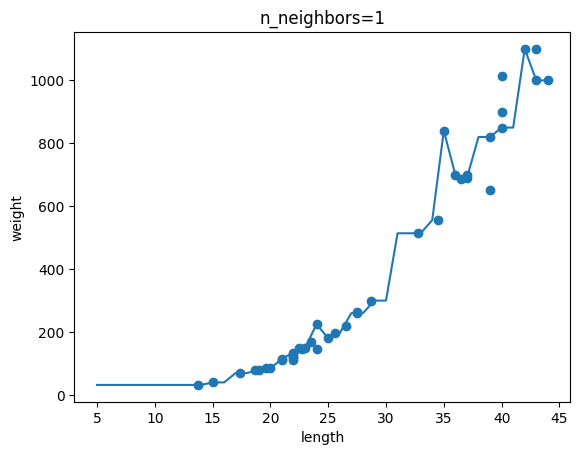

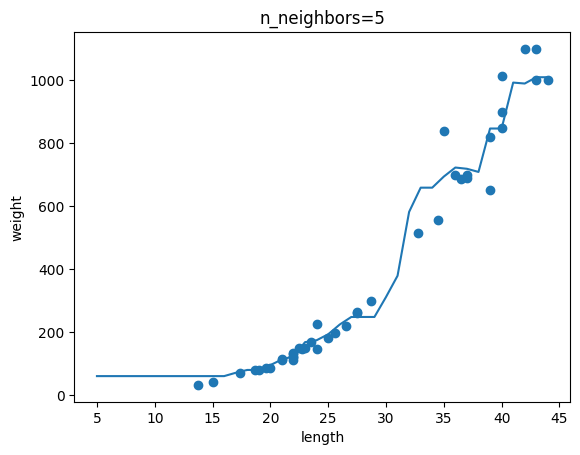

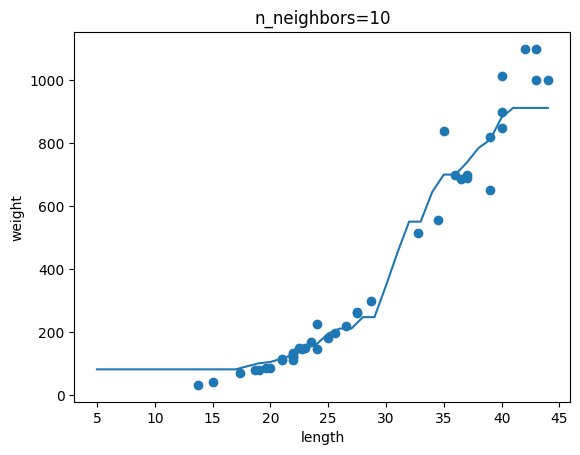

In [27]:
knr = KNeighborsRegressor()
# 농어의 length  5 ~ 45까지 x 좌표
x = np.arange(5, 45).reshape(-1, 1)  # predict() 에 전달하기 위해 feature vector 형태로 만듬.

# n = 1, 5, 10 일때 예측 결과를 시각화
for n in [1, 5, 10]:
  # 모델훈련
  knr.n_neighbors = n
  knr.fit(train_input, train_target)

  # 지정한 범위 x 에 대한 예측
  prediction = knr.predict(x)

  # 그래프 그리기
  plt.scatter(train_input, train_target)
  plt.plot(x, prediction)
  plt.title(f'n_neighbors={n}')
  plt.xlabel('length')
  plt.ylabel('weight')
  plt.show()


# KNN Regressor 의 문제점

In [28]:
# length 50cm 농어의 무게를 예측해보자!~

In [29]:
train_input.shape, test_input.shape

((42, 1), (14, 1))

In [30]:
# k-최근접 이웃 개수를 3으로 하는 회귀 모델을 훈련합니다
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [31]:
# 50cm 길이 농어의 무게 예측
knr.predict([[50]])

array([1033.33333333])

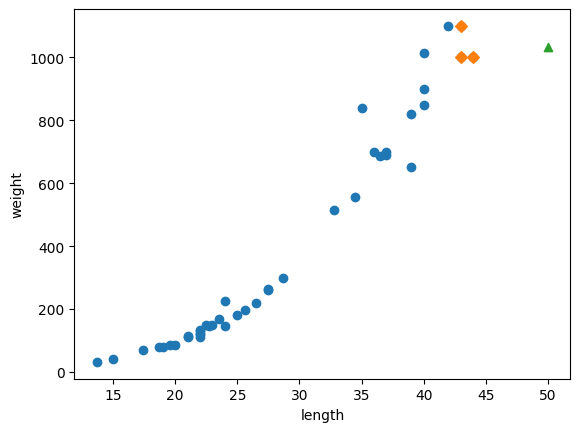

In [33]:
# 50cm 길이 농어의 무게 예측을 위해 참조한 이웃(들)
distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
# 50cm 농어
plt.scatter(50, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()



In [34]:
# 이웃 샘플의 타겟 평균 구하기
np.mean(train_target[indexes])

1033.3333333333333

In [ ]:
"""
↑ 모델이 예측했던 값과 정확히 일치합니다. KNN 은 가장 가까운 샘플을 찾아 target 을 평균합니다.
따라서 새로운 샘플이 train 세트를 벗어나면 엉뚱한 값을 예측할수 있습니다.
"""
None


In [35]:
# 50cm 뿐 아니라 길이 100cm 농어의 무게도 1033 이라 예측한다.
knr.predict([[100]])

array([1033.33333333])

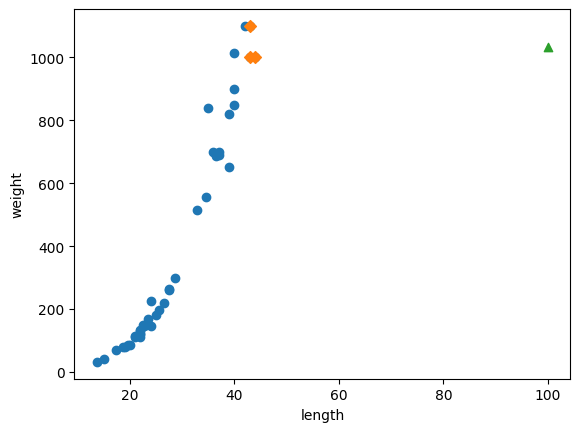

In [36]:
# 100cm 길이 농어의 무게 예측을 위해 참조한 이웃(들)
distances, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
# 100cm 농어
plt.scatter(100, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


# 선형 회귀 (Linear Regression)

In [37]:
"""
선형회귀는
특성(feature) 가 한개인경우 어떤 '직선' 을 학습하는 알고리즘.
즉 특성을 가장 잘 나타낼수 있는 직선을 찾아야 함.
"""
None

In [38]:
from sklearn.linear_model import LinearRegression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
```python
class sklearn.linear_model.LinearRegression(
  *,
  fit_intercept=True,
  copy_X=True,
  n_jobs=None,
  positive=False)
```

In [39]:
lr = LinearRegression()
lr.fit(train_input, train_target)

LinearRegression()

In [40]:
# 50cm 농어의 무게는?
lr.predict([[50]])

array([1241.83860323])

In [ ]:
"""
↑ KNN 을 사용했을때보다 농어의 무게를 아주 높게 예측함.


선형회귀는 농어의 무게를 예측하는 '직선' 을 학습하였을테고
이는 아래와 같다.

농어의 무게 = a x length + b
"""
None

In [ ]:
# LinearRegression 이 찾은
#  기울기 : coef_    <- 머신러닝에서는 이를 '기울기', '계수' 혹은 '가중치(weight)' 라고도 부름.
#  절편 : intercept_

In [41]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


- 모델 파라미터 (Model parameter)
  - 머신러닝 알고리즘이 찾아낸 값

- 모델 기반 학습 (Model based learning)
  - 최적의 모델 파라미터를 찾는 학습
  - LinearRegression 은 모델 기반 학습

- 사례 기반 학습 (Instance based learning)
  - 훈련 데이터를 저장한것만으로도 훈련하여 학습
  - KNN 알고리즘은 사례 기반 학습


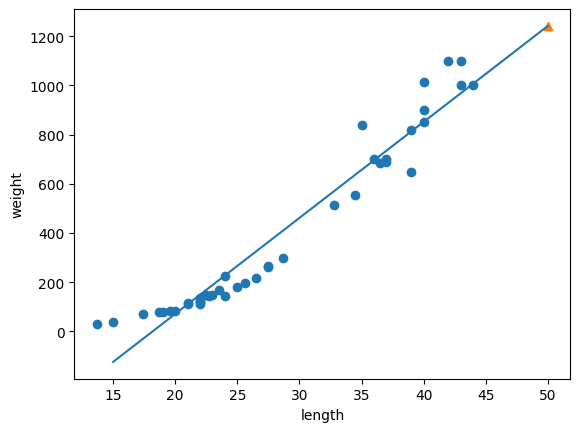

In [43]:
# 농어의 길이 15 ~ 50 까지 시각화

plt.scatter(train_input, train_target)

# 1차방정식 그릭
plt.plot([15, 50], [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_])


# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
# TODO